In [1]:
import subprocess, sys; subprocess.run([sys.executable, "-m", "pip", "install", "scikit-image", "matplotlib", "numpy", "opencv-python-headless", "scipy", "Pillow"], check=False)

# ── Importaciones ────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from PIL import Image
import urllib.request
import os, io, warnings

from skimage import data, exposure, filters, morphology, util
from skimage.color import rgb2gray
from skimage.util import img_as_float, img_as_ubyte
from scipy import ndimage

warnings.filterwarnings('ignore')

In [2]:
# ── Estilo global de gráficas ─────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'figure.titlesize': 14,
    'axes.titlesize':   12,
    'axes.titlecolor':  '#58a6ff',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

# ── Función utilitaria: mostrar imagen + histograma ───────────
def mostrar_imagen_histograma(imgs, titulos, figsize=(18, 5), cmap_list=None):
    """
    Muestra N imágenes con sus histogramas en una figura.
    imgs     : lista de arrays numpy (uint8 o float)
    titulos  : lista de strings con nombres
    """
    n = len(imgs)
    fig, axes = plt.subplots(2, n, figsize=figsize)
    if n == 1:
        axes = axes.reshape(2, 1)
    
    colores_hist = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657']
    
    for i, (img, titulo) in enumerate(zip(imgs, titulos)):
        cmap = 'gray' if (cmap_list is None or len(cmap_list) <= i) else cmap_list[i]
        # Imagen
        axes[0, i].imshow(img if img.ndim == 3 else img, cmap=cmap)
        axes[0, i].set_title(titulo, fontsize=10, pad=8)
        axes[0, i].axis('off')
        # Histograma
        img_norm = img_as_float(img) if img.dtype != np.float64 else img
        if img.ndim == 3:
            for c, col in enumerate(['#f78166', '#3fb950', '#58a6ff']):
                axes[1, i].hist(img[:,:,c].ravel(), bins=128, color=col,
                                alpha=0.5, density=True)
        else:
            axes[1, i].hist(img_norm.ravel(), bins=128,
                            color=colores_hist[i % len(colores_hist)],
                            density=True, alpha=0.85)
        axes[1, i].set_xlabel('Nivel de intensidad')
        axes[1, i].set_ylabel('Densidad')
        axes[1, i].grid(True)
    
    fig.tight_layout(pad=2)
    plt.show()

# ── Función utilitaria: métricas de calidad ───────────────────
def calcular_metricas(img_original, img_procesada):
    """
    Calcula métricas básicas de evaluación de calidad de imagen.
    Retorna un diccionario con MSE, PSNR, contraste (STD) y entropía.
    """
    o = img_as_float(img_original)
    p = img_as_float(img_procesada)
    mse  = np.mean((o - p) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')
    std_o = np.std(o)
    std_p = np.std(p)
    # Entropía
    def entropia(img):
        hist, _ = np.histogram(img, bins=256, range=(0, 1), density=True)
        hist = hist[hist > 0]
        return -np.sum(hist * np.log2(hist + 1e-10)) * (1/256)
    return {
        'MSE':           round(mse, 6),
        'PSNR (dB)':     round(psnr, 2),
        'Contraste STD orig':  round(float(std_o), 4),
        'Contraste STD proc':  round(float(std_p), 4),
        'Entropía orig':       round(float(entropia(o)), 4),
        'Entropía proc':       round(float(entropia(p)), 4),
    }

print('✅ Entorno configurado correctamente. ¡Puedes continuar!')


✅ Entorno configurado correctamente. ¡Puedes continuar!


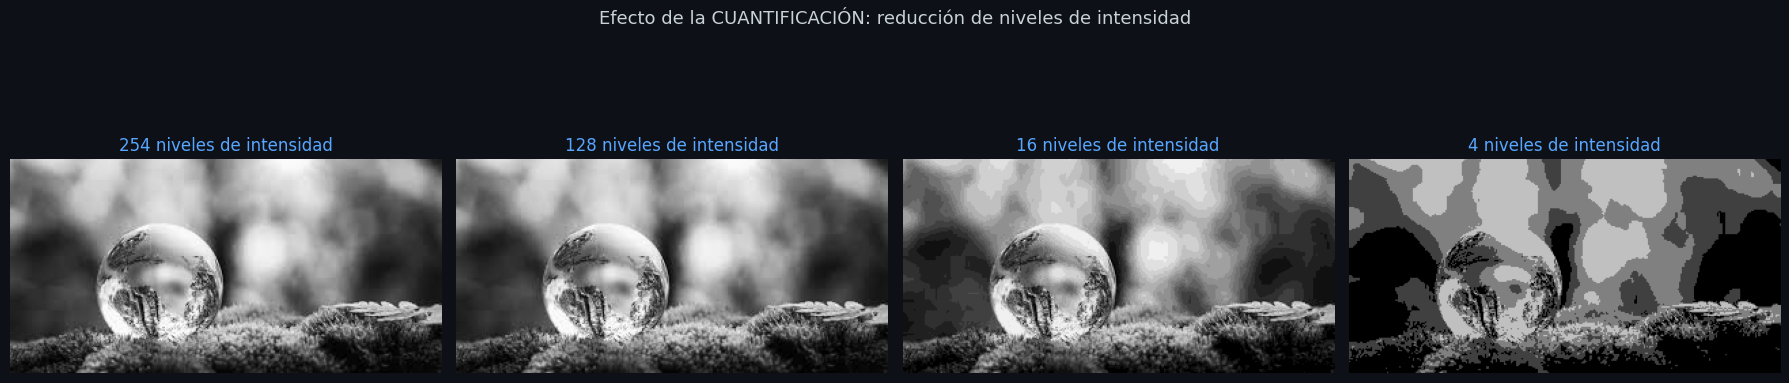


📌 INTERPRETACIÓN:
  • Con 256 niveles (8 bits): la imagen presenta transiciones suaves y
    alto detalle visual.
  • Con 64 niveles (6 bits): comienzan a apreciarse ligeras bandas
    (efecto 'posterization').
  • Con 16 niveles (4 bits): los contornos son notorios y se pierde
    información de texturas finas.
  • Con 4 niveles (2 bits): la imagen queda prácticamente binaria;
    solo se distinguen objetos grandes.

  ➤ Conclusión: 8 bits (256 niveles) es el estándar de facto para
    imágenes en escala de grises. Para imágenes médicas o satelitales
    se usan 12 o 16 bits.



In [43]:
img_original = np.array(Image.open("descarga.jpeg").convert("L"))

niveles = [254, 128, 16, 4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Efecto de la CUANTIFICACIÓN: reducción de niveles de intensidad', fontsize=13)

for ax, L in zip(axes, niveles):
    # Reducir a L niveles uniformes
    factor = 256 // L
    img_cuant = (img_original // factor) * factor
    ax.imshow(img_cuant, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{L} niveles de intensidad')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
📌 INTERPRETACIÓN:
  • Con 256 niveles (8 bits): la imagen presenta transiciones suaves y
    alto detalle visual.
  • Con 64 niveles (6 bits): comienzan a apreciarse ligeras bandas
    (efecto 'posterization').
  • Con 16 niveles (4 bits): los contornos son notorios y se pierde
    información de texturas finas.
  • Con 4 niveles (2 bits): la imagen queda prácticamente binaria;
    solo se distinguen objetos grandes.

  ➤ Conclusión: 8 bits (256 niveles) es el estándar de facto para
    imágenes en escala de grises. Para imágenes médicas o satelitales
    se usan 12 o 16 bits.
""")

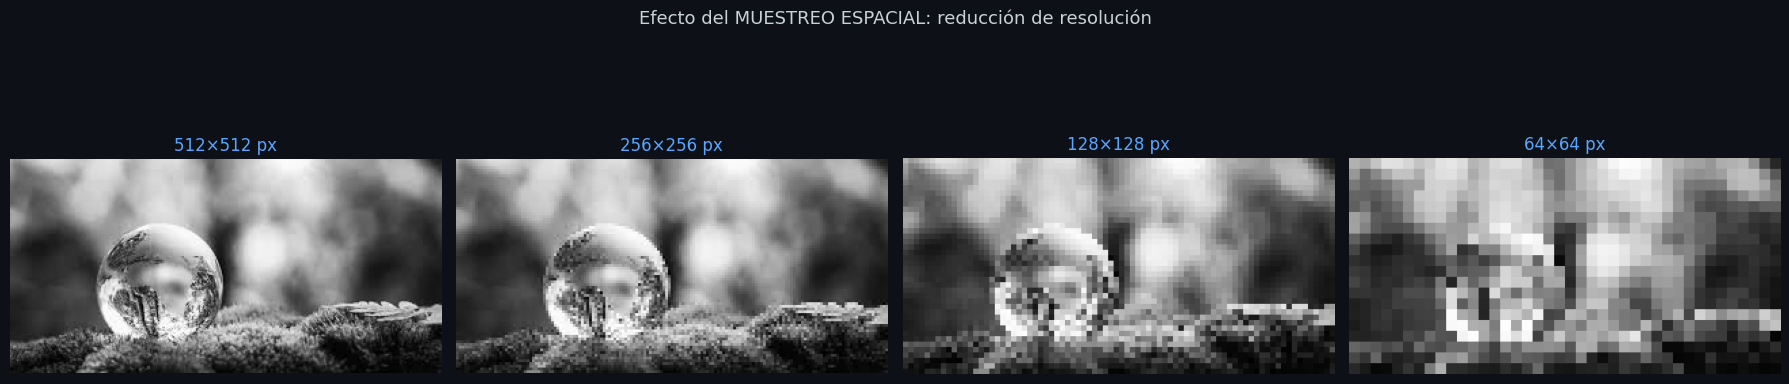


📌 INTERPRETACIÓN:
  • 512×512: imagen de referencia, sin pérdida.
  • 256×256: calidad aceptable, ligera pérdida de detalle fino.
  • 128×128: comienza a apreciarse el efecto pixelado (aliasing).
  • 64×64: la imagen es irreconocible en sus detalles.

  ➤ Teorema de Nyquist: la frecuencia de muestreo debe ser al menos
    el DOBLE de la frecuencia máxima presente en la señal.



In [15]:
img_hr = np.array(Image.open("descarga.jpeg").convert("L"))
  # 512×512 píxeles
resoluciones = [512, 256, 128, 64]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Efecto del MUESTREO ESPACIAL: reducción de resolución', fontsize=13)

for ax, res in zip(axes, resoluciones):
    # Submuestrear y luego ampliar para visualización uniforme
    factor = 512 // res
    img_sub = img_hr[::factor, ::factor]  # submuestreo
    img_vis = np.kron(img_sub, np.ones((factor, factor), dtype=np.uint8))  # ampliar
    ax.imshow(img_vis, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{res}×{res} px')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
📌 INTERPRETACIÓN:
  • 512×512: imagen de referencia, sin pérdida.
  • 256×256: calidad aceptable, ligera pérdida de detalle fino.
  • 128×128: comienza a apreciarse el efecto pixelado (aliasing).
  • 64×64: la imagen es irreconocible en sus detalles.

  ➤ Teorema de Nyquist: la frecuencia de muestreo debe ser al menos
    el DOBLE de la frecuencia máxima presente en la señal.
""")

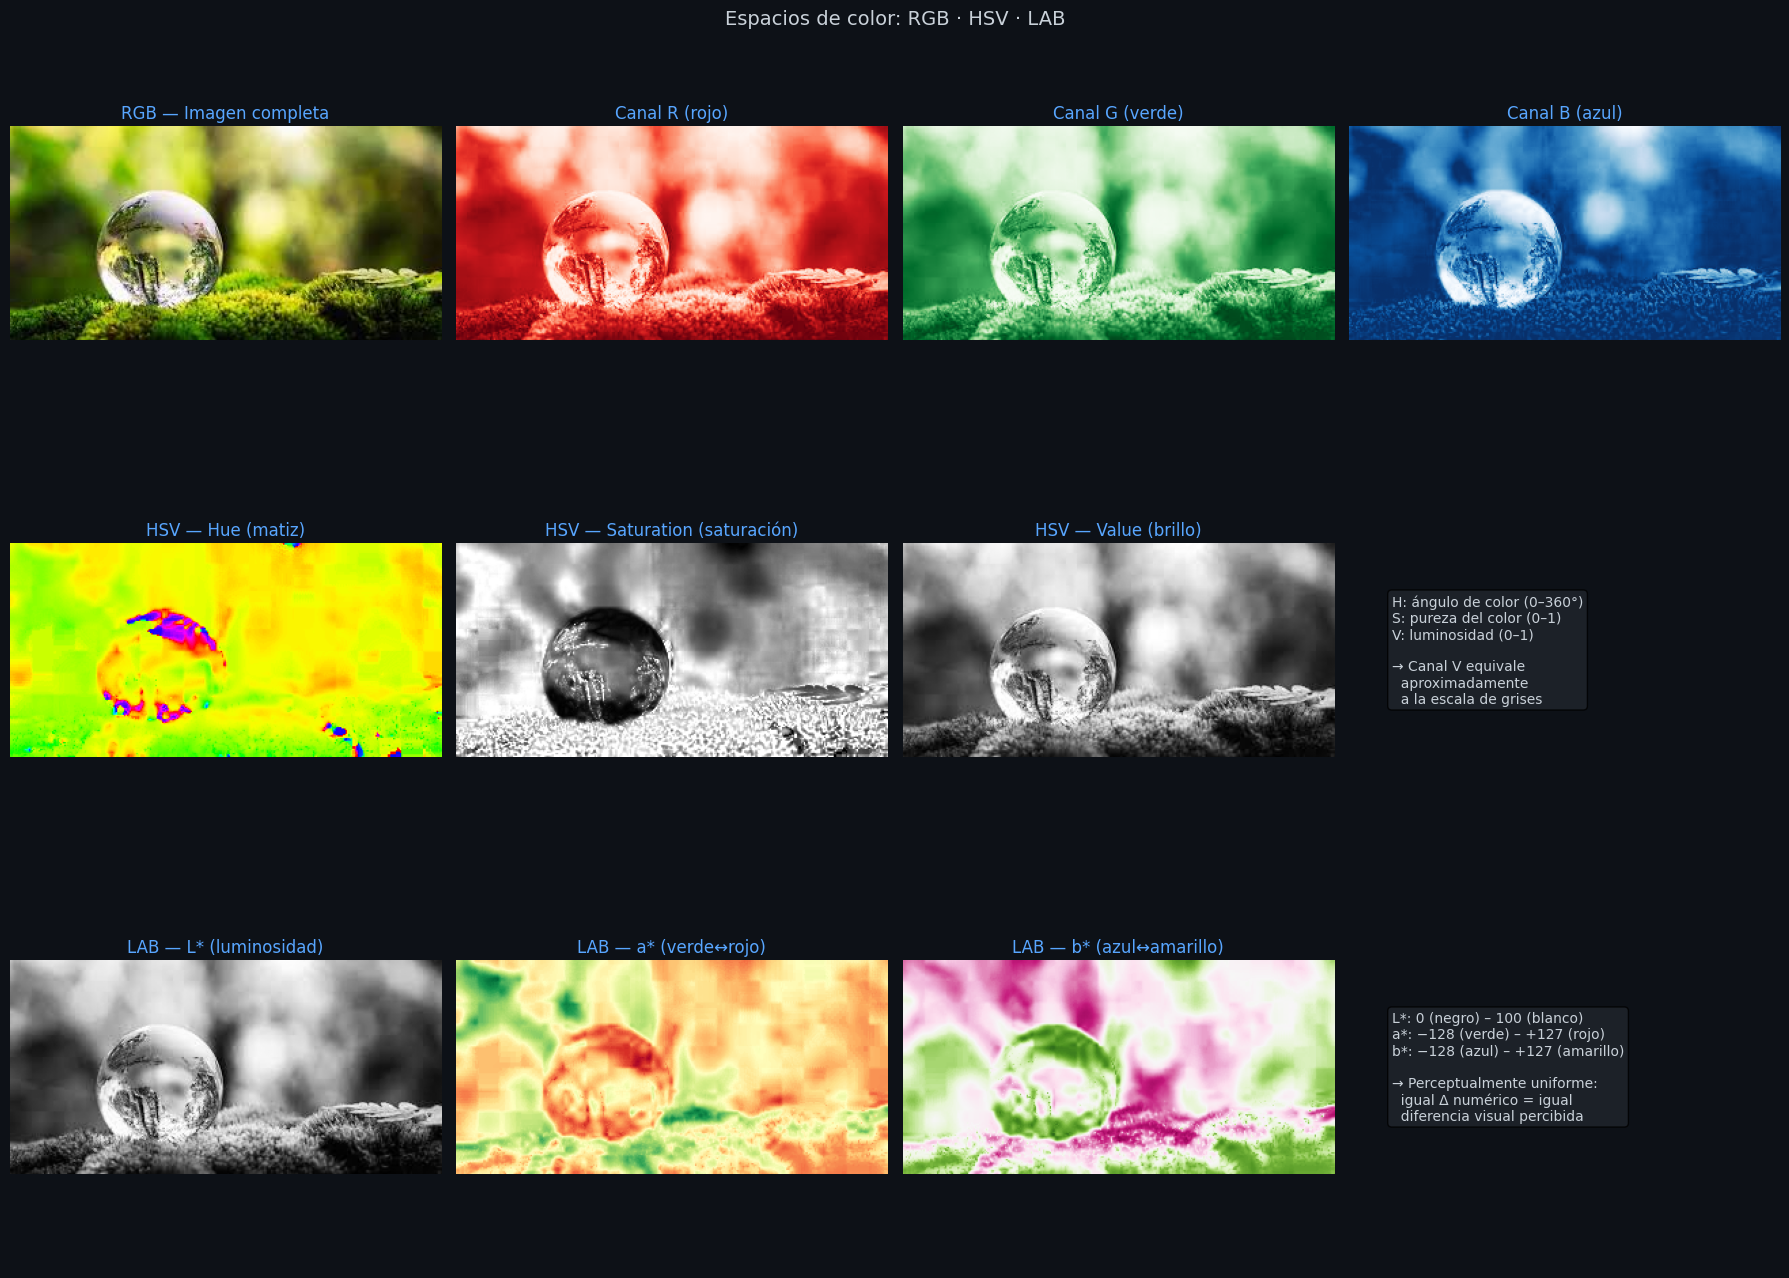

In [18]:
from skimage.color import rgb2hsv, rgb2lab

# Imagen de color de ejemplo
img_color = np.array(Image.open("descarga.jpeg"))   # 512×512×3, uint8 RGB

# Conversiones
img_hsv  = rgb2hsv(img_color)
img_lab  = rgb2lab(img_color)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle('Espacios de color: RGB · HSV · LAB', fontsize=14)

# Fila 1: RGB
nombres_rgb = ['RGB — Imagen completa', 'Canal R (rojo)', 'Canal G (verde)', 'Canal B (azul)']
datos_rgb   = [img_color,
               img_color[:,:,0], img_color[:,:,1], img_color[:,:,2]]
cmaps_rgb   = [None, 'Reds_r', 'Greens_r', 'Blues_r']
for ax, dato, nombre, cmap in zip(axes[0], datos_rgb, nombres_rgb, cmaps_rgb):
    ax.imshow(dato, cmap=cmap)
    ax.set_title(nombre)
    ax.axis('off')

# Fila 2: HSV
nombres_hsv = ['HSV — Hue (matiz)', 'HSV — Saturation (saturación)', 'HSV — Value (brillo)', '']
datos_hsv   = [img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2], None]
cmaps_hsv   = ['hsv', 'gray', 'gray', None]
for ax, dato, nombre, cmap in zip(axes[1], datos_hsv, nombres_hsv, cmaps_hsv):
    if dato is not None:
        ax.imshow(dato, cmap=cmap)
        ax.set_title(nombre)
    ax.axis('off')
# Texto explicativo
axes[1, 3].text(0.1, 0.5,
    'H: ángulo de color (0–360°)\nS: pureza del color (0–1)\nV: luminosidad (0–1)\n\n'
    '→ Canal V equivale\n  aproximadamente\n  a la escala de grises',
    transform=axes[1, 3].transAxes, fontsize=10, va='center',
    bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

# Fila 3: LAB
# Normalizar para visualización
L_norm = (img_lab[:,:,0] - img_lab[:,:,0].min()) / (img_lab[:,:,0].max() - img_lab[:,:,0].min() + 1e-8)
a_norm = (img_lab[:,:,1] - img_lab[:,:,1].min()) / (img_lab[:,:,1].max() - img_lab[:,:,1].min() + 1e-8)
b_norm = (img_lab[:,:,2] - img_lab[:,:,2].min()) / (img_lab[:,:,2].max() - img_lab[:,:,2].min() + 1e-8)
datos_lab  = [L_norm, a_norm, b_norm, None]
nombres_lab = ['LAB — L* (luminosidad)', 'LAB — a* (verde↔rojo)', 'LAB — b* (azul↔amarillo)', '']
cmaps_lab  = ['gray', 'RdYlGn_r', 'PiYG_r', None]
for ax, dato, nombre, cmap in zip(axes[2], datos_lab, nombres_lab, cmaps_lab):
    if dato is not None:
        ax.imshow(dato, cmap=cmap)
        ax.set_title(nombre)
    ax.axis('off')
axes[2, 3].text(0.1, 0.5,
    'L*: 0 (negro) – 100 (blanco)\na*: −128 (verde) – +127 (rojo)\nb*: −128 (azul) – +127 (amarillo)\n\n'
    '→ Perceptualmente uniforme:\n  igual Δ numérico = igual\n  diferencia visual percibida',
    transform=axes[2, 3].transAxes, fontsize=10, va='center',
    bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

plt.tight_layout()
plt.show()

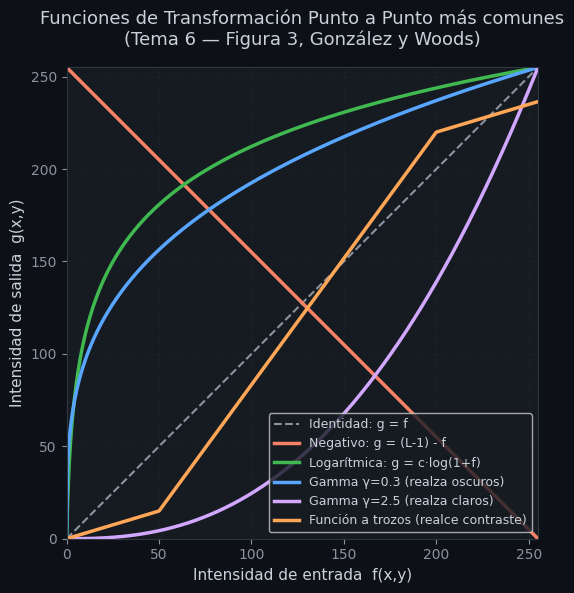


📌 INTERPRETACIÓN DE LAS CURVAS:
  • La diagonal (identidad) significa: sin transformación.
  • Curvas POR ENCIMA de la diagonal: aumentan la luminosidad.
  • Curvas POR DEBAJO de la diagonal: oscurecen la imagen.
  • Una pendiente EMPINADA en un rango concreto: aumenta el contraste en ese rango.
  • Una pendiente PLANA: comprime ese rango de intensidades.



In [20]:
L = 256  # número máximo de niveles de intensidad
r = np.linspace(0, L-1, 500)  # rango de entrada

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Funciones de Transformación Punto a Punto más comunes\n(Tema 6 — Figura 3, González y Woods)', fontsize=13)

# 1. Identidad
ax.plot(r, r, color='#8b949e', linewidth=1.5, linestyle='--', label='Identidad: g = f')

# 2. Negativo
ax.plot(r, L-1-r, color='#f78166', linewidth=2.5, label='Negativo: g = (L-1) - f')

# 3. Logarítmica (c ajustado para escalar a [0, 255])
c_log = (L-1) / np.log(1 + (L-1))
ax.plot(r, c_log * np.log(1 + r), color='#3fb950', linewidth=2.5, label='Logarítmica: g = c·log(1+f)')

# 4. Ley de potencia — gamma < 1 (realce oscuros)
ax.plot(r, (r/(L-1))**0.3 * (L-1), color='#58a6ff', linewidth=2.5, label='Gamma γ=0.3 (realza oscuros)')

# 5. Ley de potencia — gamma > 1 (realce claros)
ax.plot(r, (r/(L-1))**2.5 * (L-1), color='#d2a8ff', linewidth=2.5, label='Gamma γ=2.5 (realza claros)')

# 6. Realce de contraste (función a trozos)
f_piecewise = np.where(r < 50,  r * 0.3,
              np.where(r < 200, (r - 50) * (205 / 150) + 15,
                                (r - 200) * 0.3 + 220))
ax.plot(r, f_piecewise, color='#ffa657', linewidth=2.5, label='Función a trozos (realce contraste)')

ax.set_xlabel('Intensidad de entrada  f(x,y)', fontsize=11)
ax.set_ylabel('Intensidad de salida  g(x,y)', fontsize=11)
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("""
📌 INTERPRETACIÓN DE LAS CURVAS:
  • La diagonal (identidad) significa: sin transformación.
  • Curvas POR ENCIMA de la diagonal: aumentan la luminosidad.
  • Curvas POR DEBAJO de la diagonal: oscurecen la imagen.
  • Una pendiente EMPINADA en un rango concreto: aumenta el contraste en ese rango.
  • Una pendiente PLANA: comprime ese rango de intensidades.
""")

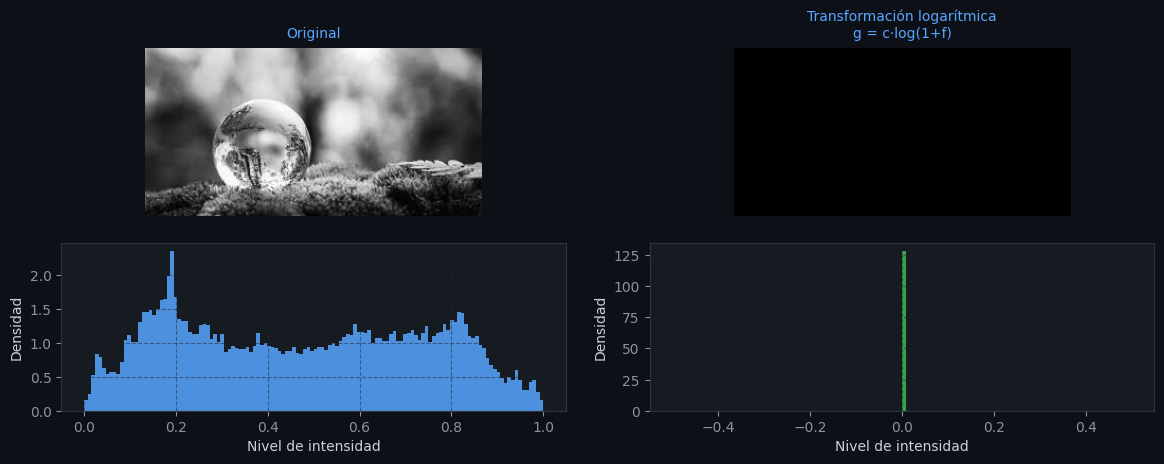

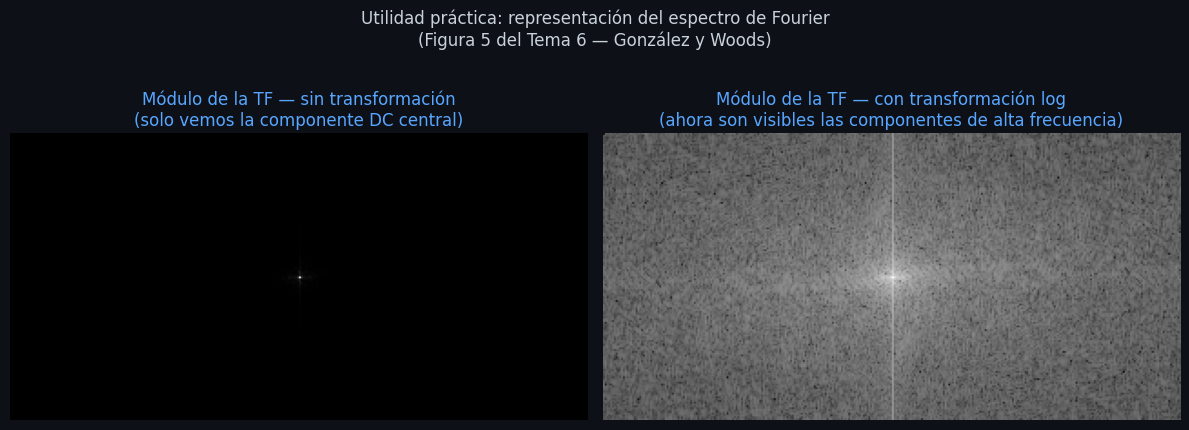

📌 Rango dinámico espectro: 8 – 6092863
   La diferencia es de orden 726370x
   Sin log: solo el punto central (componente DC) es visible.
   Con log: toda la distribución espectral es apreciable.


In [47]:
img_gris= np.array(Image.open("descarga.jpeg").convert("L"))
# Constante c para escalar la salida a [0, 255]
c = -255/ np.log(1 + img_gris.max())
img_log = (c * np.log(1 + img_gris)).astype(np.uint8)

# ── Ejemplo 2: Espectro de Fourier ──────────────────────────
# El espectro tiene rango dinámico MUY alto; sin log solo vemos un punto
F = np.fft.fft2(img_gris)
F_shift = np.fft.fftshift(F)
magnitud = np.abs(F_shift)
espectro_sin_log = (magnitud / magnitud.max() * 255).astype(np.uint8)
c2 = 255 / np.log(1 + magnitud.max())
espectro_con_log = (c2 * np.log(1 + magnitud)).astype(np.uint8)

# ── Figura 1: imagen general ─────────────────────────────────
mostrar_imagen_histograma(
    [img_gris, img_log],
    ['Original', 'Transformación logarítmica\ng = c·log(1+f)'],
    figsize=(12, 5)
)

# ── Figura 2: espectro de Fourier ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Utilidad práctica: representación del espectro de Fourier\n'
             '(Figura 5 del Tema 6 — González y Woods)', fontsize=12)
axes[0].imshow(espectro_sin_log, cmap='gray')
axes[0].set_title('Módulo de la TF — sin transformación\n(solo vemos la componente DC central)')
axes[0].axis('off')
axes[1].imshow(espectro_con_log, cmap='gray')
axes[1].set_title('Módulo de la TF — con transformación log\n(ahora son visibles las componentes de alta frecuencia)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'📌 Rango dinámico espectro: {magnitud.min():.0f} – {magnitud.max():.0f}')
print(f'   La diferencia es de orden {magnitud.max()/magnitud.min():.0f}x')
print('   Sin log: solo el punto central (componente DC) es visible.')
print('   Con log: toda la distribución espectral es apreciable.')


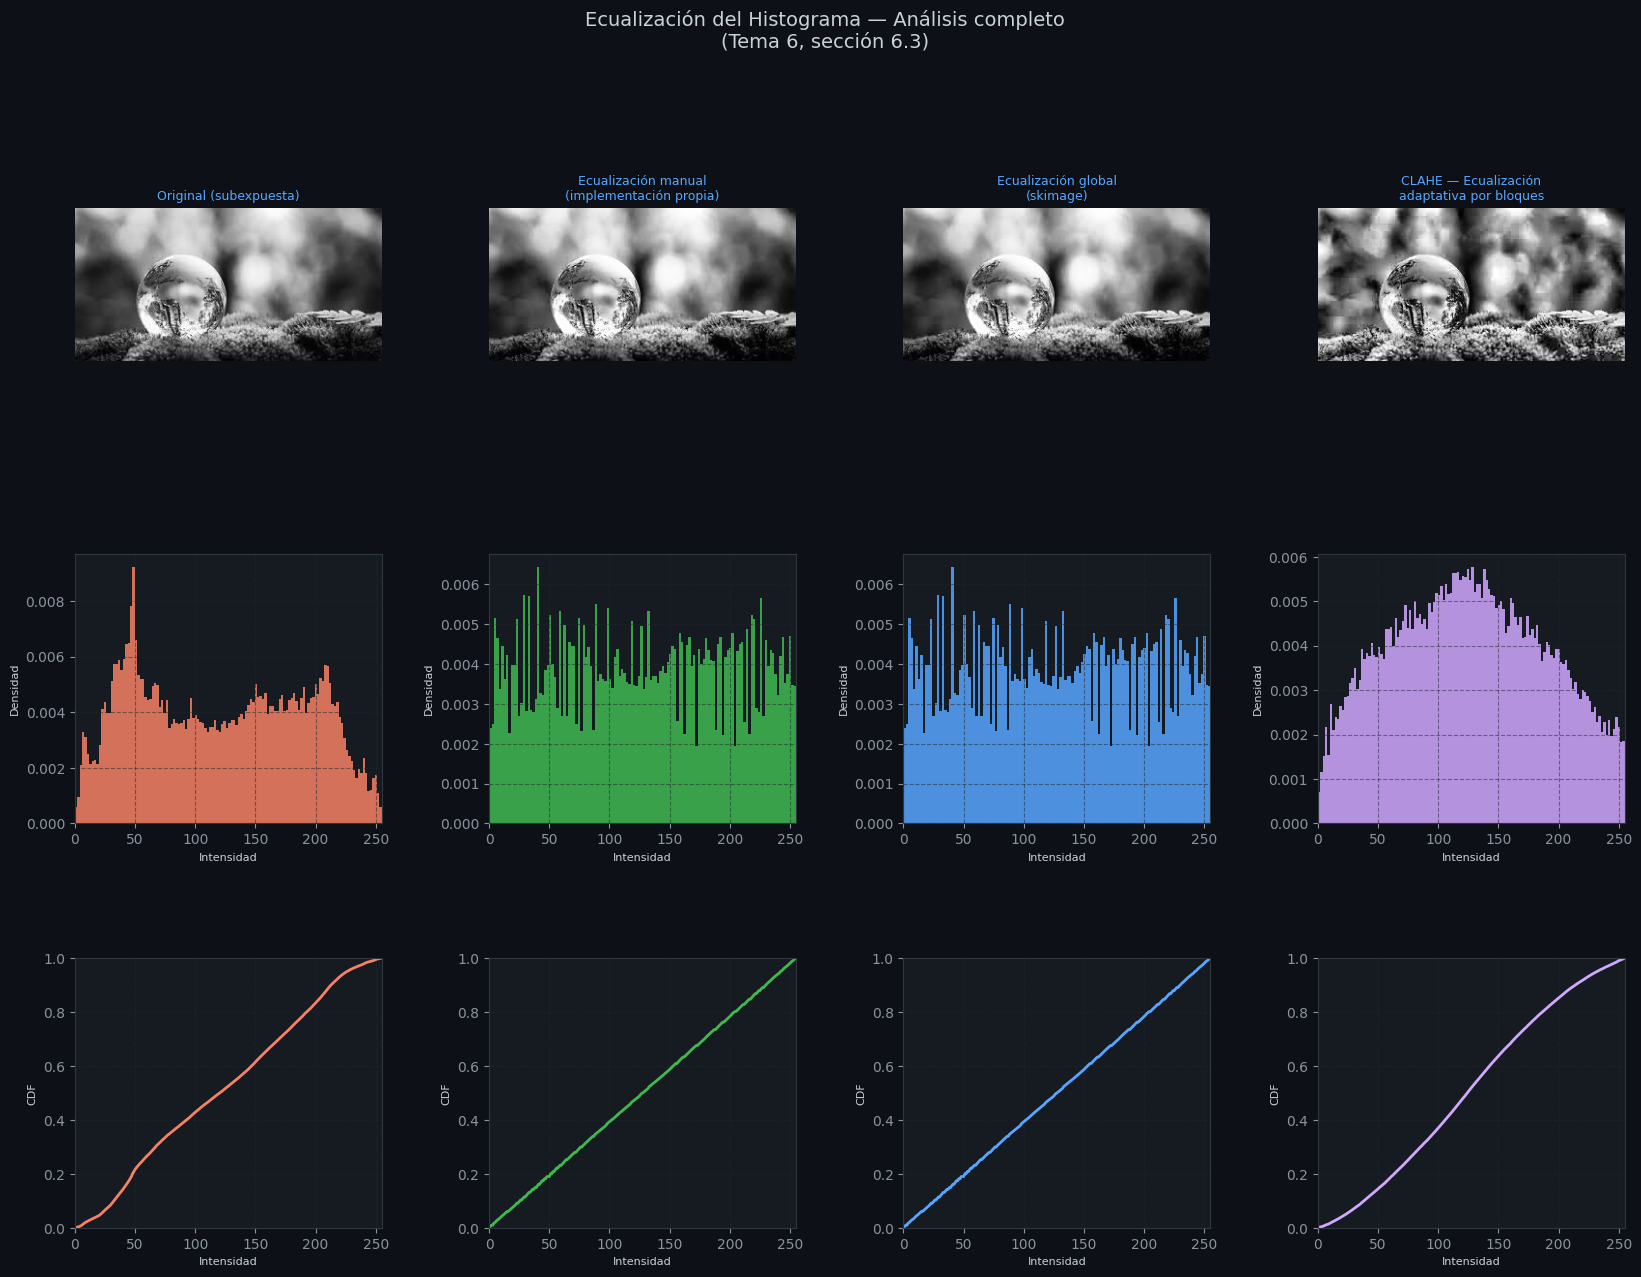


📊 Comparación de métricas:
Técnica                                μ (media)      σ (std)      Min      Max
--------------------------------------------------------------------------------
Original                                   121.3        68.45        0      255
Ecualización manual                        128.0        73.56        0      255
Ecualización global                        128.0        73.56        0      255
CLAHE                                      125.7        63.65        0      255


In [51]:
def equalizar_histograma(img):
    """
    Implementación manual de ecualización de histograma.
    Sigue el algoritmo del Tema 6 paso a paso.
    """
    # Paso 1: Calcular histograma normalizado (PDF)
    hist, bins = np.histogram(img.ravel(), bins=256, range=(0, 256))
    pdf = hist / float(img.size)
    
    # Paso 2: Calcular CDF (función de distribución acumulada)
    cdf = np.cumsum(pdf)
    
    # Paso 3: Escalar la CDF al rango [0, 255]
    lut = np.round(cdf * 255).astype(np.uint8)
    
    # Paso 4: Aplicar la LUT (Look-Up Table)
    return lut[img], pdf, cdf, lut

# Aplicar a imagen oscura
img_entrada=img_gris
img_eq_manual, pdf_orig, cdf_orig, lut = equalizar_histograma(img_entrada)

# Con skimage (versión AHE y CLAHE)
img_eq_global  = exposure.equalize_hist(img_entrada)
img_eq_clahe   = exposure.equalize_adapthist(img_entrada, clip_limit=0.03)

# ── Figura principal ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Ecualización del Histograma — Análisis completo\n'
             '(Tema 6, sección 6.3)', fontsize=14)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)

imgs_eq   = [img_entrada, img_eq_manual,
             img_as_ubyte(img_eq_global), img_as_ubyte(img_eq_clahe)]
titulos_eq = ['Original (subexpuesta)',
              'Ecualización manual\n(implementación propia)',
              'Ecualización global\n(skimage)',
              'CLAHE — Ecualización\nadaptativa por bloques']
colores_eq = ['#f78166', '#3fb950', '#58a6ff', '#d2a8ff']

for i, (img_i, titulo_i, color_i) in enumerate(zip(imgs_eq, titulos_eq, colores_eq)):
    # Imagen
    ax_img = fig.add_subplot(gs[0, i])
    ax_img.imshow(img_i, cmap='gray', vmin=0, vmax=255)
    ax_img.set_title(titulo_i, fontsize=9)
    ax_img.axis('off')
    # Histograma
    ax_h = fig.add_subplot(gs[1, i])
    ax_h.hist(img_i.ravel(), bins=128, color=color_i, density=True, alpha=0.85)
    ax_h.set_xlim(0, 255)
    ax_h.set_xlabel('Intensidad', fontsize=8)
    ax_h.set_ylabel('Densidad', fontsize=8)
    ax_h.grid(True)
    # CDF
    ax_cdf = fig.add_subplot(gs[2, i])
    h_i, b_i = np.histogram(img_i.ravel(), bins=256, range=(0,255))
    cdf_i = np.cumsum(h_i / float(img_i.size))
    ax_cdf.plot(cdf_i, color=color_i, linewidth=2)
    ax_cdf.set_xlim(0, 255)
    ax_cdf.set_ylim(0, 1)
    ax_cdf.set_xlabel('Intensidad', fontsize=8)
    ax_cdf.set_ylabel('CDF', fontsize=8)
    ax_cdf.grid(True)

plt.show()

# ── Métricas comparativas ────────────────────────────────────
print('\n📊 Comparación de métricas:')
print(f'{"Técnica":<35} {"μ (media)":>12} {"σ (std)":>12} {"Min":>8} {"Max":>8}')
print('-' * 80)
tecnicas = ['Original', 'Ecualización manual', 'Ecualización global', 'CLAHE']
for nombre, img_m in zip(tecnicas, imgs_eq):
    print(f'{nombre:<35} {img_m.mean():>12.1f} {img_m.std():>12.2f} '
          f'{img_m.min():>8} {img_m.max():>8}')